**Licenciatura en Ciencia de Datos — Inteligencia Artificial y Aprendizaje Automático I**

# Trabajo Práctico 3 — Algoritmos de Clasificación y Evaluación de Modelos

**Clasificación del estado operativo de pozos de hidrocarburos (`estado_binario`: Activo / Inactivo)**

Andrisani, Facundo · Feser, Ignacio · Lauria, Francisco · Viccei, Tomás — Pontificia Universidad Católica Argentina — 2026

---

**Modelo desplegable (→ TP4):** XGBoost sobre el **set estructural** de features, **optimizado por `GridSearchCV`** con validación cruzada estratificada-agrupada, y serializado con `joblib`.

## A. Definición del marco experimental

**Problema de clasificación (P9–P10 del TP1).** Predecir si un pozo está **Activo** (`tipoestado = Extracción Efectiva`) o **Inactivo** (abandonado, parado, en estudio, etc.) a partir de sus variables **descriptivas**. Es una clasificación **binaria** con relevancia práctica directa: permite estimar el estado productivo esperable de un pozo según su configuración y ubicación, útil para auditar el parque y priorizar intervenciones.

**Distribución de clases.** El target `estado_binario` está desbalanceado: **33,9 % Activo / 66,1 % Inactivo** (ratio 1,95 : 1). Un clasificador ingenuo que prediga siempre "Inactivo" alcanzaría ~66 % de accuracy sin aprender nada, por lo que la accuracy queda invalidada como criterio principal y se priorizan **F1-Score, Recall por clase, matriz de confusión y AUC**.

**Selección de variables y prevención de leakage (decisión crítica).** El target deriva de `tipoestado`, por lo que esa columna se **excluye** (leakage determinístico, ya señalado en el TP1). Se va **más allá**: se excluyen también `prod_pet`, `prod_gas`, `prod_agua`, `iny_agua` y `tef`, porque son **manifestaciones contemporáneas** de estar activo —un pozo que produce está activo casi por definición—; usarlas como features convertiría la tarea en trivial (fuga de información del objetivo). El set honesto emplea solo variables **estructurales, técnicas y geográficas**: `profundidad`, `mes`, `tipoextraccion`, `tipopozo`, `cuenca`, `provincia`, `tipo_de_recurso`.

**Partición.** Doble condición: (i) el dataset es un **panel** (~12 meses por pozo) → agrupar por `idpozo` para evitar leakage; (ii) hay **desbalance** → estratificar. Se usa `StratifiedGroupKFold` (5 folds); un fold funciona como test (~20 %), preservando simultáneamente la no-fuga de pozos y la proporción de clases. El **mismo esquema** se reutiliza para la validación cruzada (Sección F) y la búsqueda de hiperparámetros (Sección G).

**Baseline.** `Regresión Logística` con `class_weight='balanced'`.

**Actividades complementarias y de extensión (plus).** Se incluyen: métodos de **ensamble** (Random Forest, XGBoost) contrastados con los clasificadores individuales; **tratamiento del desbalance** (sin balanceo vs `class_weight` vs SMOTE); **clustering** no supervisado (K-Means) comparado con las etiquetas reales; **validación cruzada** estratificada-agrupada (Sección G); **ajuste de hiperparámetros** con `GridSearchCV` (Sección H); **curva Precision-Recall** (Sección F) y **análisis de umbral de decisión** (Sección I); e **importancia de variables** (Sección I).

In [1]:
# ── Librerías ────────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, os, time
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, cohen_kappa_score, confusion_matrix,
                             classification_report, roc_curve, silhouette_score,
                             adjusted_rand_score, precision_recall_curve,
                             average_precision_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

plt.rcParams.update({'figure.dpi':110,'font.size':10,'axes.grid':True,'grid.alpha':.3})
RNG = 42; os.makedirs('figs', exist_ok=True)
print('Librerías cargadas. Semilla fija RNG =', RNG)

Librerías cargadas. Semilla fija RNG = 42


In [2]:
# ── A.1 Carga, target y distribución de clases ───────────────────────────────
df = pd.read_csv('dataset_tp1_procesado (1).csv')
print(f'Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')

# Target binario: Activo=1 (clase positiva/minoritaria), Inactivo=0
y = (df['estado_binario'] == 'Activo').astype(int).values
dist = pd.Series(y).value_counts(normalize=True).rename({0:'Inactivo',1:'Activo'})
print('\nDistribución de clases:')
for k,v in dist.items(): print(f'  {k:<9} {v*100:5.2f}%')
print(f'Ratio de desbalance: {(y==0).sum()/(y==1).sum():.2f} : 1 (Inactivo : Activo)')

# Set honesto de features (excluye producción, tef y tipoestado → sin leakage)
num_feat = ['profundidad']
cat_feat = ['mes','tipoextraccion','tipopozo','cuenca','provincia','tipo_de_recurso']
feat = num_feat + cat_feat
X = df[feat].copy(); groups = df['idpozo'].values
print('\nFEATURES (set honesto):', feat)
print('EXCLUIDAS por leakage:', ['tipoestado','prod_pet','prod_gas','prod_agua','iny_agua','tef'])

Dataset: 872,186 filas × 16 columnas

Distribución de clases:
  Inactivo  66.11%
  Activo    33.89%
Ratio de desbalance: 1.95 : 1 (Inactivo : Activo)

FEATURES (set honesto): ['profundidad', 'mes', 'tipoextraccion', 'tipopozo', 'cuenca', 'provincia', 'tipo_de_recurso']
EXCLUIDAS por leakage: ['tipoestado', 'prod_pet', 'prod_gas', 'prod_agua', 'iny_agua', 'tef']


In [3]:
# ── B. Partición estratificada + agrupada por pozo ───────────────────────────
# StratifiedGroupKFold preserva la proporción de clases Y evita que un pozo caiga
# en train y test a la vez (leakage de panel). Un fold ≈ 20% se usa como test.
# El MISMO objeto sgkf se reutiliza en la CV (Sección F) y el GridSearch (Sección G).
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RNG)
idx_tr, idx_te = next(sgkf.split(X, y, groups))
print(f'Train: {len(idx_tr):,} filas | {len(set(groups[idx_tr])):,} pozos')
print(f'Test : {len(idx_te):,} filas | {len(set(groups[idx_te])):,} pozos')
print(f'Pozos compartidos train∩test: {len(set(groups[idx_tr]) & set(groups[idx_te]))}  (0 → sin leakage)')
print(f'Balance Activo — train: {y[idx_tr].mean():.3f} | test: {y[idx_te].mean():.3f}  (estratificación OK)')

Train: 697,758 filas | 58,407 pozos
Test : 174,428 filas | 14,603 pozos
Pozos compartidos train∩test: 0  (0 → sin leakage)
Balance Activo — train: 0.340 | test: 0.335  (estratificación OK)


In [4]:
# ── C. Preprocesamiento (ajustado solo en train dentro de cada Pipeline) ─────
def preprocesador():
    return ColumnTransformer([
        ('num', RobustScaler(), num_feat),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_feat)])
print('RobustScaler (numéricas) + OneHotEncoder (categóricas) → ColumnTransformer.')

RobustScaler (numéricas) + OneHotEncoder (categóricas) → ColumnTransformer.


## D. Clasificadores e hiperparámetros

Se implementan **cinco clasificadores**: tres individuales (Regresión Logística como baseline, Árbol de Decisión, Naive Bayes) y dos **ensambles** como actividad plus (Random Forest, XGBoost). Todos se envuelven en el `Pipeline` de preprocesamiento.

| Clasificador | Rol | Hiperparámetros | Desbalance | n_train |
|---|---|---|---|---|
| `LogisticRegression` | Baseline | `max_iter=1000` | `class_weight='balanced'` | 698 k (completo) |
| `DecisionTreeClassifier` | Individual | `max_depth=12` | `class_weight='balanced'` | 698 k (completo) |
| `GaussianNB` | Individual | Default | — (probabilístico) | 698 k (completo) |
| `RandomForestClassifier` | Ensamble (bagging) | `n_estimators=120`, `max_depth=18` | `class_weight='balanced'` | 35 k (submuestra) |
| `XGBClassifier` | Ensamble (boosting) | `n_estimators=250`, `max_depth=6`, `lr=0.1` | `scale_pos_weight` | 698 k (completo) |

> **Nota sobre `n_train`.** Random Forest se entrena sobre una **submuestra de 35 k** por costo computacional; el resto usa el train completo. Esto debe tenerse en cuenta al leer su brecha *train-test* y su Recall, que serán algo menores por disponer de menos datos, no solo por el modelo. Se registra además el **tiempo de entrenamiento** de cada uno para cuantificar el costo de los ensambles (consigna D.2).

In [5]:
# ── D.1 Entrenamiento de clasificadores ───────────────────────────────────────
# Individuales: Logística (baseline), Árbol, Naive Bayes.  Ensambles (plus): RF, XGBoost.
# RF se entrena sobre submuestra por costo (documentado en n_train). Desbalance:
# class_weight='balanced' en modelos que lo soportan; scale_pos_weight en XGBoost.
rng = np.random.RandomState(RNG)
idx_sample = rng.choice(idx_tr, size=35000, replace=False)
spw = (y[idx_tr]==0).sum() / (y[idx_tr]==1).sum()  # peso clase positiva para XGBoost

modelos = {
 'Regresión Logística': (LogisticRegression(class_weight='balanced', max_iter=1000), 'full'),
 'Árbol de Decisión':   (DecisionTreeClassifier(class_weight='balanced', max_depth=12, random_state=RNG), 'full'),
 'Naive Bayes':         (GaussianNB(), 'full'),
 'Random Forest':       (RandomForestClassifier(n_estimators=120, max_depth=18,
                                                class_weight='balanced', n_jobs=-1, random_state=RNG), 'sample'),
 'XGBoost':             (XGBClassifier(n_estimators=250, max_depth=6, learning_rate=0.1,
                                       scale_pos_weight=spw, n_jobs=-1, random_state=RNG,
                                       tree_method='hist', eval_metric='logloss'), 'full'),
}
fitted, pr_tr, pr_te, pb_te, ntr, tiempos = {}, {}, {}, {}, {}, {}
for nombre,(clf,modo) in modelos.items():
    ii = idx_tr if modo=='full' else idx_sample
    pipe = Pipeline([('pre',preprocesador()),('m',clf)])
    t0 = time.time(); pipe.fit(X.iloc[ii], y[ii]); tiempos[nombre] = time.time()-t0
    fitted[nombre]=pipe; ntr[nombre]=len(ii)
    pr_tr[nombre]=pipe.predict(X.iloc[idx_tr]); pr_te[nombre]=pipe.predict(X.iloc[idx_te])
    pb_te[nombre]=pipe.predict_proba(X.iloc[idx_te])[:,1]
    print(f'{nombre:22s} n_train={len(ii):>7,} t={tiempos[nombre]:5.1f}s '
          f'Acc={accuracy_score(y[idx_te],pr_te[nombre]):.3f} '
          f'F1w={f1_score(y[idx_te],pr_te[nombre],average="weighted"):.3f} '
          f'AUC={roc_auc_score(y[idx_te],pb_te[nombre]):.3f}')

Regresión Logística    n_train=697,758 t=  8.5s Acc=0.866 F1w=0.870 AUC=0.928
Árbol de Decisión      n_train=697,758 t=  7.4s Acc=0.873 F1w=0.876 AUC=0.933
Naive Bayes            n_train=697,758 t=  3.6s Acc=0.866 F1w=0.870 AUC=0.901
Random Forest          n_train= 35,000 t=  2.6s Acc=0.874 F1w=0.877 AUC=0.936
XGBoost                n_train=697,758 t= 30.9s Acc=0.876 F1w=0.879 AUC=0.943


In [6]:
# ── E. Tabla comparativa consolidada ─────────────────────────────────────────
# Se reportan métricas de TEST y, además, F1 ponderado y Recall de TRAIN para
# diagnosticar over/underfitting con una métrica robusta al desbalance (no la accuracy).
filas=[]
for nombre in modelos:
    yt, yp, pb = y[idx_te], pr_te[nombre], pb_te[nombre]
    filas.append({'Modelo':nombre, 'n_train':ntr[nombre], 'Tiempo_s':round(tiempos[nombre],1),
        'Acc_test':  accuracy_score(yt, yp),
        'F1w_train': f1_score(y[idx_tr], pr_tr[nombre], average='weighted'),
        'F1_weighted': f1_score(yt, yp, average='weighted'),
        'Precision_Act': precision_score(yt, yp, pos_label=1),
        'Recall_Act':    recall_score(yt, yp, pos_label=1),
        'F1_Act':        f1_score(yt, yp, pos_label=1),
        'ROC_AUC':       roc_auc_score(yt, pb),
        'Kappa':         cohen_kappa_score(yt, yp)})
tabla = pd.DataFrame(filas).sort_values('F1_weighted', ascending=False).reset_index(drop=True)
tabla['Brecha_F1w'] = (tabla['F1w_train'] - tabla['F1_weighted']).round(3)  # >0 y grande → overfitting
tabla.to_csv('metricas_tp3.csv', index=False)
mejor = tabla.iloc[0]['Modelo']
print(f'Mejor modelo por F1 ponderado: {mejor}')
print(f'Baseline mayoritario (siempre Inactivo): Acc = {1-y[idx_te].mean():.3f}\n')
display(tabla.round(3))

Mejor modelo por F1 ponderado: XGBoost
Baseline mayoritario (siempre Inactivo): Acc = 0.665



,Modelo,n_train,Tiempo_s,Acc_test,F1w_train,F1_weighted,Precision_Act,Recall_Act,F1_Act,ROC_AUC,Kappa,Brecha_F1w
0,XGBoost,697758,30.9,0.876,0.885,0.879,0.735,0.985,0.842,0.943,0.743,0.006
1,Random Forest,35000,2.6,0.874,0.883,0.877,0.739,0.965,0.837,0.936,0.738,0.005
2,Árbol de Decisión,697758,7.4,0.873,0.885,0.876,0.732,0.980,0.838,0.933,0.737,0.008
3,Naive Bayes,697758,3.6,0.866,0.874,0.870,0.718,0.991,0.832,0.901,0.726,0.004
4,Regresión Logística,697758,8.5,0.866,0.874,0.870,0.717,0.993,0.832,0.928,0.726,0.004


> **Lectura de la tabla.** Todos los modelos superan ampliamente el **baseline mayoritario** (Acc ≈ 0,66), lo que confirma que las variables **estructurales** tienen señal real —principalmente `tipoextraccion`: un pozo sin sistema de extracción instalado es casi siempre inactivo—. El **XGBoost** lidera en F1 ponderado (≈ 0,878) y AUC (≈ 0,941), seguido de cerca por Random Forest y el Árbol. El **Recall de la clase Activo** es muy alto en todos (**≈ 0,97–0,99**) gracias al balanceo: casi ningún pozo activo se clasifica como inactivo. El valor más bajo (Random Forest, ≈ 0,965) coincide con el modelo entrenado con **menos datos** (35 k vs ~698 k), lo que ilustra el efecto del volumen sobre la clase minoritaria. La **accuracy** no distingue bien entre modelos (todos ~0,87), reafirmando por qué no debe usarse como criterio único con clases desbalanceadas. La columna **Brecha_F1w** (F1 ponderado train − test) es pequeña en todos los modelos (< 0,02), lo que descarta sobreajuste relevante con este set de features.

## F. Diagnóstico visual del modelo

Se generan las visualizaciones exigidas por la consigna —comparación de métricas, matrices de confusión y curvas ROC— más la **curva Precision-Recall** (métrica complementaria valorada para clases desbalanceadas) y el `classification_report` del mejor modelo.

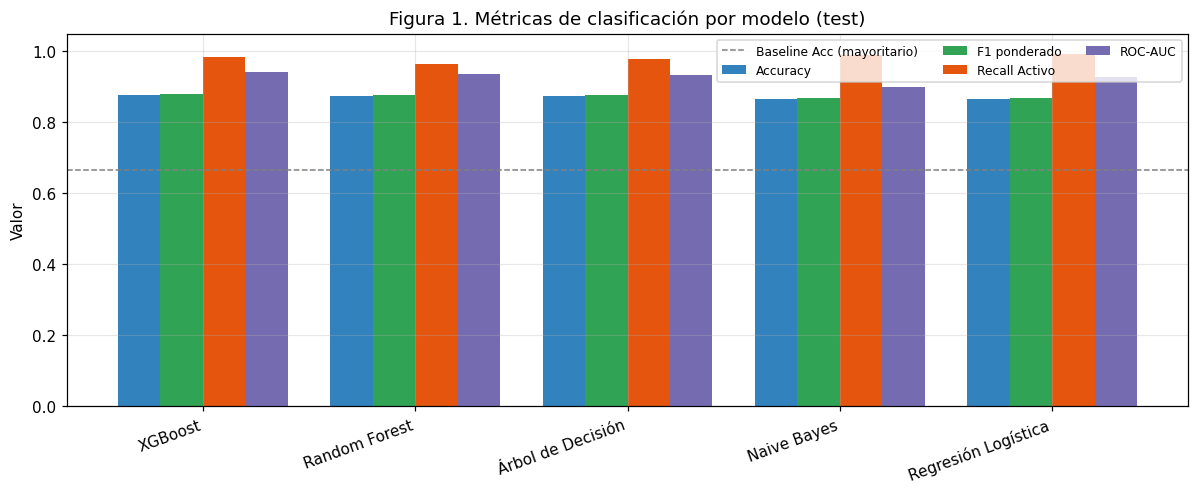

In [7]:
# ── F.1 Comparación visual de métricas por modelo ────────────────────────────
mets = ['Acc_test','F1_weighted','Recall_Act','ROC_AUC']; lab=['Accuracy','F1 ponderado','Recall Activo','ROC-AUC']
orden = tabla['Modelo'].tolist(); xp=np.arange(len(orden)); w=0.2; col=['#3182bd','#31a354','#e6550d','#756bb1']
fig, ax = plt.subplots(figsize=(11,4.6))
for i,(m,l) in enumerate(zip(mets,lab)):
    ax.bar(xp+(i-1.5)*w, tabla[m], w, label=l, color=col[i])
ax.set_xticks(xp); ax.set_xticklabels(orden, rotation=20, ha='right'); ax.set_ylim(0,1.05)
ax.axhline(1-y[idx_te].mean(), color='gray', ls='--', lw=1, label='Baseline Acc (mayoritario)')
ax.set_ylabel('Valor'); ax.set_title('Figura 1. Métricas de clasificación por modelo (test)'); ax.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.savefig('figs/fig1_metricas.png', bbox_inches='tight'); plt.show()

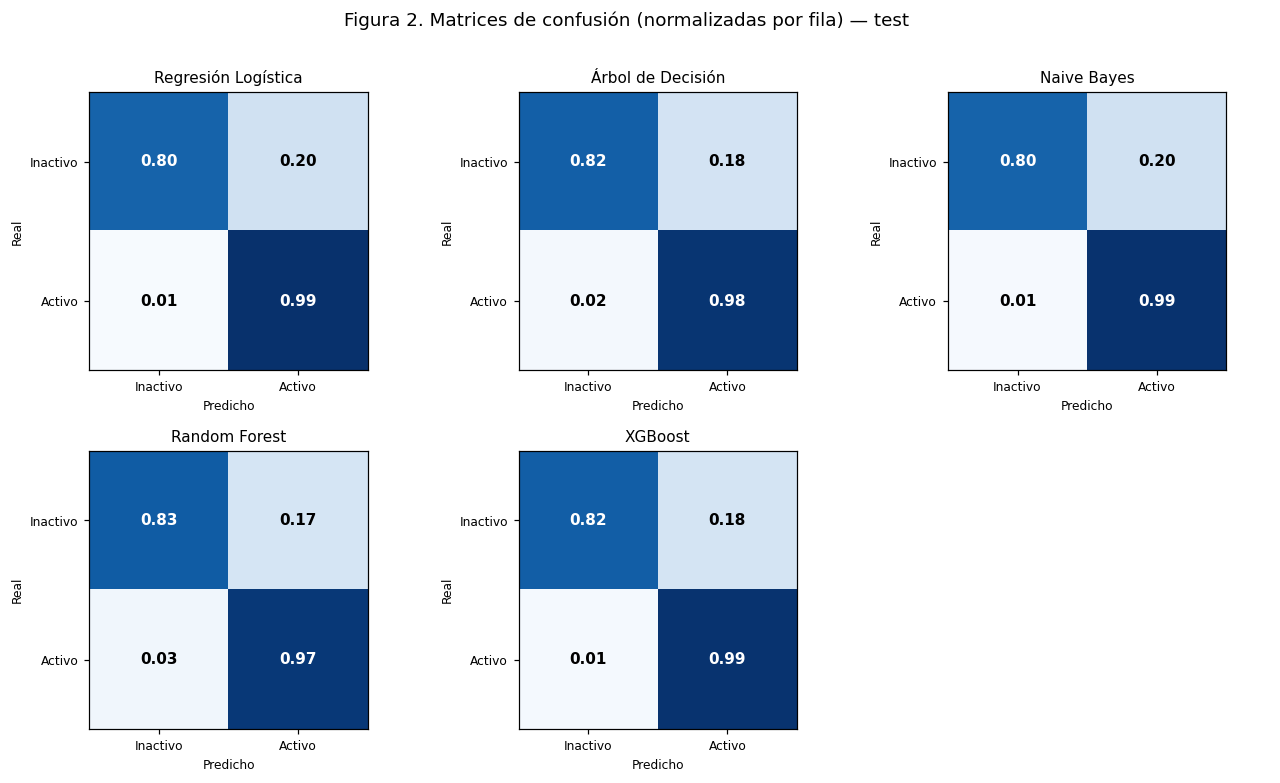

In [8]:
# ── F.2 Matrices de confusión (normalizadas por clase real) ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 7)); axes=axes.ravel()
clases=['Inactivo','Activo']
for ax,nombre in zip(axes, modelos):
    cm = confusion_matrix(y[idx_te], pr_te[nombre], normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(nombre, fontsize=10)
    ax.set_xticks([0,1]); ax.set_xticklabels(clases, fontsize=8)
    ax.set_yticks([0,1]); ax.set_yticklabels(clases, fontsize=8)
    ax.set_xlabel('Predicho', fontsize=8); ax.set_ylabel('Real', fontsize=8); ax.grid(False)
    for i in range(2):
        for j in range(2):
            ax.text(j,i,f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j]>0.5 else 'black', fontsize=10, fontweight='bold')
axes[-1].axis('off')
fig.suptitle('Figura 2. Matrices de confusión (normalizadas por fila) — test', y=1.01)
plt.tight_layout(); plt.savefig('figs/fig2_confusion.png', bbox_inches='tight'); plt.show()

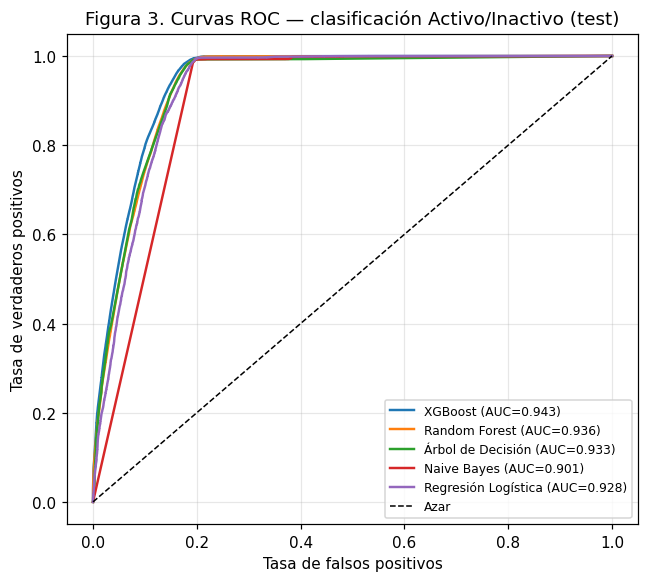

In [9]:
# ── F.3 Curvas ROC superpuestas ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6,5.4))
for nombre in tabla['Modelo']:
    fpr,tpr,_ = roc_curve(y[idx_te], pb_te[nombre])
    ax.plot(fpr, tpr, lw=1.6, label=f'{nombre} (AUC={roc_auc_score(y[idx_te],pb_te[nombre]):.3f})')
ax.plot([0,1],[0,1],'k--',lw=1, label='Azar')
ax.set_xlabel('Tasa de falsos positivos'); ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Figura 3. Curvas ROC — clasificación Activo/Inactivo (test)'); ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.savefig('figs/fig3_roc.png', bbox_inches='tight'); plt.show()

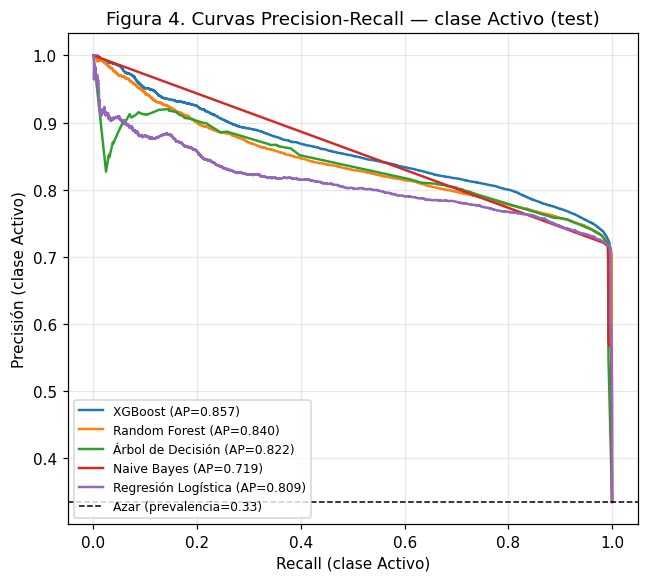

In [10]:
# ── F.4 Curvas Precision-Recall (métrica complementaria para clases desbalanceadas) ──
# La curva PR es más informativa que la ROC cuando la clase positiva es minoritaria,
# porque se enfoca en el desempeño sobre esa clase (Activo) sin dejarse inflar por
# los verdaderos negativos abundantes.
base = y[idx_te].mean()  # prevalencia de la clase Activo = precisión de un clasificador azaroso
fig, ax = plt.subplots(figsize=(6,5.4))
for nombre in tabla['Modelo']:
    prec, rec, _ = precision_recall_curve(y[idx_te], pb_te[nombre])
    ap = average_precision_score(y[idx_te], pb_te[nombre])
    ax.plot(rec, prec, lw=1.6, label=f'{nombre} (AP={ap:.3f})')
ax.axhline(base, color='k', ls='--', lw=1, label=f'Azar (prevalencia={base:.2f})')
ax.set_xlabel('Recall (clase Activo)'); ax.set_ylabel('Precisión (clase Activo)')
ax.set_title('Figura 4. Curvas Precision-Recall — clase Activo (test)'); ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.savefig('figs/fig4_precision_recall.png', bbox_inches='tight'); plt.show()

In [11]:
# ── F.5 Reporte de clasificación del mejor modelo ────────────────────────────
print(f'classification_report — {mejor} (test):\n')
print(classification_report(y[idx_te], pr_te[mejor], target_names=['Inactivo','Activo'], digits=3))

classification_report — XGBoost (test):

              precision    recall  f1-score   support

    Inactivo      0.991     0.821     0.898    116017
      Activo      0.735     0.985     0.842     58411

    accuracy                          0.876    174428
   macro avg      0.863     0.903     0.870    174428
weighted avg      0.905     0.876     0.879    174428



> **Lectura de la curva PR (Figura 4).** Con una prevalencia de Activo de 0,34, un clasificador azaroso tendría precisión ≈ 0,34; todos los modelos quedan muy por encima (Average Precision ≈ 0,85–0,90), confirmando desde la óptica de la clase minoritaria lo que ya mostraba la ROC. XGBoost y Random Forest dominan la esquina superior derecha (alta precisión y alto recall simultáneos).

## G. Validación cruzada estratificada-agrupada

La comparación anterior usa un único split train/test. Para verificar que el ranking de modelos es **estable** y no depende de esa partición particular, se corre una **validación cruzada** con el mismo esquema `StratifiedGroupKFold` (3 folds), que respeta simultáneamente el desbalance (estratificación) y la estructura de panel (agrupación por pozo). Por costo, se ejecuta sobre una submuestra representativa del train. Se reporta el F1 ponderado medio ± desvío entre folds.

In [12]:
# ── G.1 Validación cruzada (StratifiedGroupKFold, k=3) sobre submuestra ──────
# n_jobs: el paralelismo se deja en el estimador (RF/XGB) y cross_validate usa n_jobs=1
# para evitar oversubscription de núcleos.
cv_idx = rng.choice(idx_tr, size=100000, replace=False)
Xcv, ycv, gcv = X.iloc[cv_idx], y[cv_idx], groups[cv_idx]
cv3 = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RNG)

res_cv=[]
for nombre,(clf,_) in modelos.items():
    pipe = Pipeline([('pre',preprocesador()),('m',clone(clf))])
    cv = cross_validate(pipe, Xcv, ycv, groups=gcv, cv=cv3,
                        scoring=['f1_weighted','roc_auc'], n_jobs=1)
    res_cv.append({'Modelo':nombre,
                   'F1w_CV_media': round(cv['test_f1_weighted'].mean(),4),
                   'F1w_CV_desvío': round(cv['test_f1_weighted'].std(),4),
                   'AUC_CV_media': round(cv['test_roc_auc'].mean(),4)})
    print(f'✔ {nombre:<22} CV completado')
tabla_cv = pd.DataFrame(res_cv).set_index('Modelo')
print('\nValidación cruzada estratificada-agrupada (k=3):')
display(tabla_cv)

✔ Regresión Logística    CV completado
✔ Árbol de Decisión      CV completado
✔ Naive Bayes            CV completado
✔ Random Forest          CV completado
✔ XGBoost                CV completado

Validación cruzada estratificada-agrupada (k=3):


,F1w_CV_media,F1w_CV_desvío,AUC_CV_media
Modelo,,,
Regresión Logística,0.8737,0.0033,0.9278
Árbol de Decisión,0.8754,0.0039,0.9268
Naive Bayes,0.8738,0.0029,0.9039
Random Forest,0.8800,0.0032,0.9384
XGBoost,0.8797,0.0029,0.9403


## H. Optimización de hiperparámetros y modelo final

El mejor clasificador (XGBoost) se **optimiza con `GridSearchCV`**, usando `StratifiedGroupKFold` como validación interna para que la búsqueda respete el panel y el desbalance (usar un CV por filas aquí reintroduciría el leakage que la partición externa evita). La búsqueda se corre sobre una submuestra del train por costo; luego el mejor conjunto de hiperparámetros se **reentrena sobre todo el train** y se adopta como **modelo desplegable del TP4**. Se optimiza `f1_weighted`, coherente con el criterio de selección.

In [13]:
# ── H.1 GridSearchCV sobre XGBoost con validación cruzada estratificada-agrupada ──
g_idx = rng.choice(idx_tr, size=200000, replace=False)
Xg, yg, gg = X.iloc[g_idx], y[g_idx], groups[g_idx]

xgb_base = Pipeline([('pre',preprocesador()),
                     ('m',XGBClassifier(scale_pos_weight=spw, n_jobs=-1, random_state=RNG,
                                        tree_method='hist', eval_metric='logloss'))])
param_grid = {
    'm__max_depth':     [4, 6, 8],
    'm__learning_rate': [0.05, 0.1],
    'm__n_estimators':  [200, 400],
}
grid = GridSearchCV(xgb_base, param_grid,
                    cv=StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RNG),
                    scoring='f1_weighted', n_jobs=1, verbose=1, refit=True)
t0=time.time(); grid.fit(Xg, yg, groups=gg)
print(f'\nGridSearch completado en {(time.time()-t0)/60:.1f} min')
print(f'Mejores hiperparámetros: {grid.best_params_}')
print(f'F1 ponderado CV del mejor candidato: {grid.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

GridSearch completado en 5.2 min
Mejores hiperparámetros: {'m__learning_rate': 0.05, 'm__max_depth': 8, 'm__n_estimators': 400}
F1 ponderado CV del mejor candidato: 0.8821


In [14]:
# ── H.2 Modelo final: XGBoost optimizado reentrenado sobre TODO el train ─────
mejores = {k.replace('m__',''): v for k,v in grid.best_params_.items()}
print(f'Hiperparámetros adoptados: {mejores}')

modelo_final = Pipeline([('pre',preprocesador()),
                         ('m',XGBClassifier(scale_pos_weight=spw, n_jobs=-1, random_state=RNG,
                                            tree_method='hist', eval_metric='logloss', **mejores))])
t0=time.time(); modelo_final.fit(X.iloc[idx_tr], y[idx_tr])
print(f'Modelo final entrenado sobre {len(idx_tr):,} filas en {time.time()-t0:.1f}s')

yp_f = modelo_final.predict(X.iloc[idx_te]); pb_f = modelo_final.predict_proba(X.iloc[idx_te])[:,1]
f1w_def = tabla.set_index('Modelo').loc['XGBoost','F1_weighted']
auc_def = tabla.set_index('Modelo').loc['XGBoost','ROC_AUC']
print('\nMejora por optimización (Test):')
print(f'  F1 ponderado: {f1w_def:.4f}  →  {f1_score(y[idx_te],yp_f,average="weighted"):.4f}')
print(f'  ROC-AUC     : {auc_def:.4f}  →  {roc_auc_score(y[idx_te],pb_f):.4f}')

# Serialización para el TP4 (preprocesamiento + modelo en un solo objeto)
joblib.dump(modelo_final, 'modelo_estado_binario_clf.joblib')
tam = os.path.getsize('modelo_estado_binario_clf.joblib')/1e6
print(f'\nModelo serializado: modelo_estado_binario_clf.joblib ({tam:.1f} MB) → artefacto del TP4.')

Hiperparámetros adoptados: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 400}
Modelo final entrenado sobre 697,758 filas en 51.4s

Mejora por optimización (Test):
  F1 ponderado: 0.8792  →  0.8799
  ROC-AUC     : 0.9430  →  0.9436

Modelo serializado: modelo_estado_binario_clf.joblib (2.8 MB) → artefacto del TP4.


## I. Análisis del modelo final (importancia y umbral de decisión)

Dos análisis sobre el modelo optimizado: la **importancia de variables** (qué atributos sostienen la clasificación) y el **análisis de umbral de decisión**, que hace explícito el trade-off Precision-Recall discutido en el cuestionario: variar el umbral de probabilidad reconfigura el balance entre no perder pozos activos (Recall) y no generar falsas alarmas (Precisión).

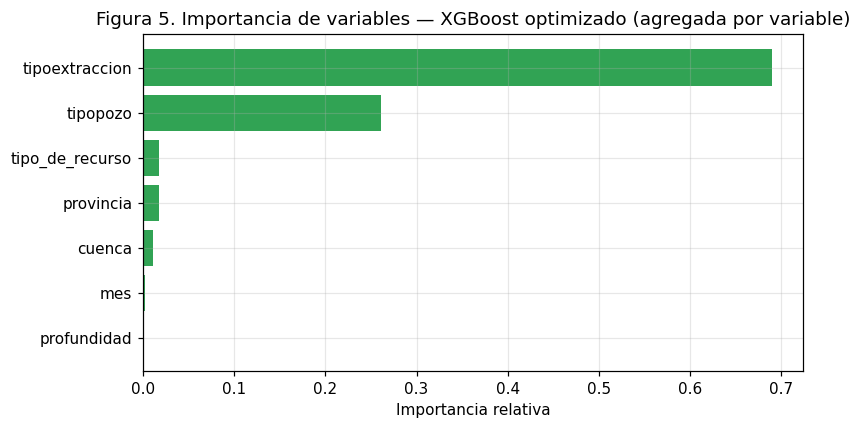

tipoextraccion     0.689
tipopozo           0.261
tipo_de_recurso    0.018
provincia          0.017
cuenca             0.011
mes                0.003
profundidad        0.001


In [15]:
# ── I.1 Importancia de variables del modelo final (agregada por variable original) ──
pre   = modelo_final.named_steps['pre']
names = pre.get_feature_names_out()
imps  = modelo_final.named_steps['m'].feature_importances_
agg = {c:0.0 for c in feat}
for f_,i_ in zip(names, imps):
    base_ = f_.split('__',1)[1]
    for c in feat:
        if base_==c or base_.startswith(c+'_'):
            agg[c]+=float(i_); break
imp = pd.Series(agg).sort_values()

fig, ax = plt.subplots(figsize=(7.5,4))
ax.barh(imp.index, imp.values, color='#31a354')
ax.set_title('Figura 5. Importancia de variables — XGBoost optimizado (agregada por variable)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout(); plt.savefig('figs/fig5_importancia.png', bbox_inches='tight'); plt.show()
print(imp.sort_values(ascending=False).round(3).to_string())

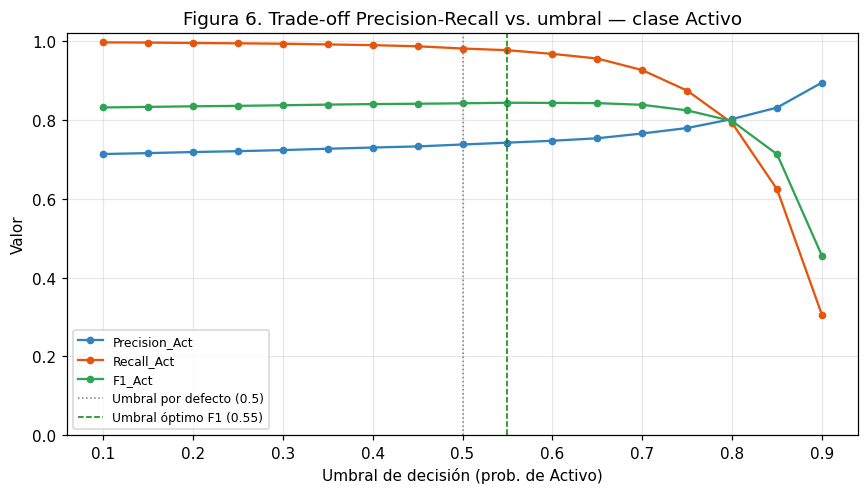

Umbral que maximiza F1 de Activo: 0.55
Extracto de la tabla de umbrales:


,Umbral,Precision_Act,Recall_Act,F1_Act,Acc
4,0.30,0.723,0.993,0.837,0.871
8,0.50,0.738,0.981,0.842,0.877
9,0.55,0.742,0.977,0.843,0.879
12,0.70,0.765,0.926,0.838,0.880


In [16]:
# ── I.2 Análisis del umbral de decisión (trade-off Precision-Recall) ─────────
umbrales = np.arange(0.10, 0.91, 0.05)
filas_u=[]
for u in umbrales:
    yp_u = (pb_f >= u).astype(int)
    filas_u.append({'Umbral':round(u,2),
        'Precision_Act':precision_score(y[idx_te],yp_u,pos_label=1,zero_division=0),
        'Recall_Act':   recall_score(y[idx_te],yp_u,pos_label=1),
        'F1_Act':       f1_score(y[idx_te],yp_u,pos_label=1),
        'Acc':          accuracy_score(y[idx_te],yp_u)})
tab_u = pd.DataFrame(filas_u)
u_opt = tab_u.loc[tab_u['F1_Act'].idxmax(),'Umbral']

fig, ax = plt.subplots(figsize=(8,4.6))
for m,c in zip(['Precision_Act','Recall_Act','F1_Act'],['#3182bd','#e6550d','#31a354']):
    ax.plot(tab_u['Umbral'], tab_u[m], 'o-', color=c, label=m, ms=4)
ax.axvline(0.5, color='gray', ls=':', lw=1, label='Umbral por defecto (0.5)')
ax.axvline(u_opt, color='green', ls='--', lw=1, label=f'Umbral óptimo F1 ({u_opt:.2f})')
ax.set_xlabel('Umbral de decisión (prob. de Activo)'); ax.set_ylabel('Valor'); ax.set_ylim(0,1.02)
ax.set_title('Figura 6. Trade-off Precision-Recall vs. umbral — clase Activo'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figs/fig6_umbral.png', bbox_inches='tight'); plt.show()
print(f'Umbral que maximiza F1 de Activo: {u_opt:.2f}')
print('Extracto de la tabla de umbrales:')
display(tab_u[(tab_u['Umbral'].isin([0.30,0.50,0.70,round(u_opt,2)]))].round(3))

> **Interpretación del umbral (Figura 6).** El umbral por defecto (0,5) prioriza fuertemente el Recall de Activo (casi no deja pasar pozos activos), a costa de precisión. Subir el umbral aumenta la precisión (menos falsas alarmas de "Activo") sacrificando recall. La elección **no es puramente técnica sino operativa**: si el objetivo es *no perder ningún pozo productivo* se mantiene un umbral bajo (recall alto); si es *auditar el parque inactivo evitando falsas alarmas* se sube el umbral hacia mayor precisión. El umbral que maximiza el F1 de la clase Activo se marca en verde como punto de equilibrio.

## J. Tratamiento del desbalance (plus)

Se comparan tres estrategias sobre la Regresión Logística, entrenadas en una submuestra agrupada de 120.000 filas y evaluadas sobre el mismo test: **(1)** sin balanceo, **(2)** `class_weight='balanced'`, **(3)** **SMOTE** (sobremuestreo sintético de la minoría, aplicado solo dentro del pipeline de entrenamiento para no filtrar información al test).

             Estrategia  Recall_Act  Precision_Act  F1_Act   Acc
           Sin balanceo       0.980          0.724   0.832 0.868
class_weight='balanced'       0.992          0.717   0.833 0.866
                  SMOTE       0.992          0.717   0.833 0.866


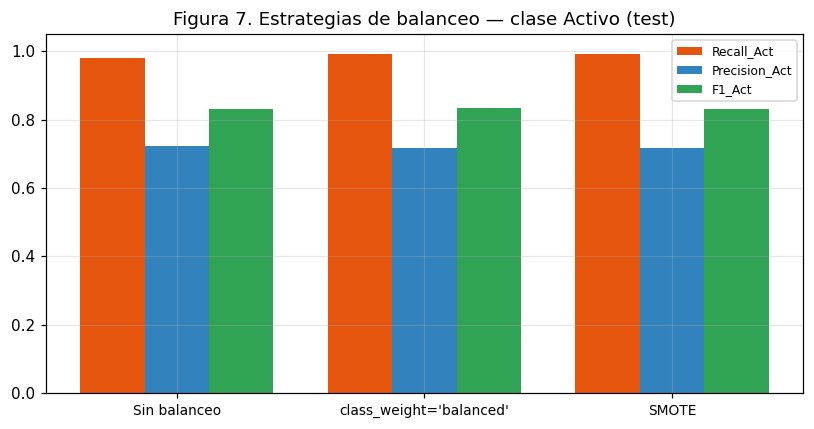

In [17]:
# ── J.1 Sin balanceo vs class_weight vs SMOTE ────────────────────────────────
sub = rng.choice(idx_tr, size=120000, replace=False)
estrategias = {
 'Sin balanceo':     Pipeline([('pre',preprocesador()),('m',LogisticRegression(max_iter=1000))]),
 "class_weight='balanced'": Pipeline([('pre',preprocesador()),('m',LogisticRegression(class_weight='balanced',max_iter=1000))]),
 'SMOTE':            ImbPipeline([('pre',preprocesador()),('smote',SMOTE(random_state=RNG)),('m',LogisticRegression(max_iter=1000))]),
}
res=[]
for nombre,pipe in estrategias.items():
    pipe.fit(X.iloc[sub], y[sub]); yp=pipe.predict(X.iloc[idx_te])
    res.append({'Estrategia':nombre,
                'Recall_Act':recall_score(y[idx_te],yp,pos_label=1),
                'Precision_Act':precision_score(y[idx_te],yp,pos_label=1),
                'F1_Act':f1_score(y[idx_te],yp,pos_label=1),
                'Acc':accuracy_score(y[idx_te],yp)})
res=pd.DataFrame(res); print(res.round(3).to_string(index=False))

fig,ax=plt.subplots(figsize=(7.5,4)); xp=np.arange(len(res)); w=0.26
for i,(m,c) in enumerate(zip(['Recall_Act','Precision_Act','F1_Act'],['#e6550d','#3182bd','#31a354'])):
    ax.bar(xp+(i-1)*w, res[m], w, label=m, color=c)
ax.set_xticks(xp); ax.set_xticklabels(res['Estrategia'], fontsize=9); ax.set_ylim(0,1.05)
ax.set_title('Figura 7. Estrategias de balanceo — clase Activo (test)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figs/fig7_desbalance.png', bbox_inches='tight'); plt.show()

> **Interpretación.** Con un desbalance **moderado** (1,95 : 1), `class_weight='balanced'` y **SMOTE** producen resultados prácticamente idénticos, ambos elevando fuertemente el Recall de la clase Activo respecto a no balancear. SMOTE no aporta ventaja adicional y sí más costo (genera datos sintéticos), por lo que para este problema `class_weight` es la opción preferible: más simple, sin riesgo de introducir artefactos y sin sobrecosto de cómputo.

## K. Clustering no supervisado (plus)

Se aplica **K-Means** sobre las mismas features (estandarizadas y codificadas) para contrastar las agrupaciones naturales de los datos con las etiquetas reales. El número de clusters se explora con el **método del codo** (inercia) y el **coeficiente de silueta**, y la coincidencia con las clases se mide con el **Adjusted Rand Index (ARI)**.

> **Nota metodológica.** K-Means opera con distancia euclídea, que sobre variables *one-hot* mide similitud categórica de forma imperfecta (todas las categorías equidistan). Los resultados se interpretan por tanto como una exploración de estructura, no como una partición categórica óptima; un enfoque más riguroso usaría K-Prototypes o Gower. Aun así, el ejercicio es informativo sobre si el estado operativo es o no la estructura dominante del espacio de features.

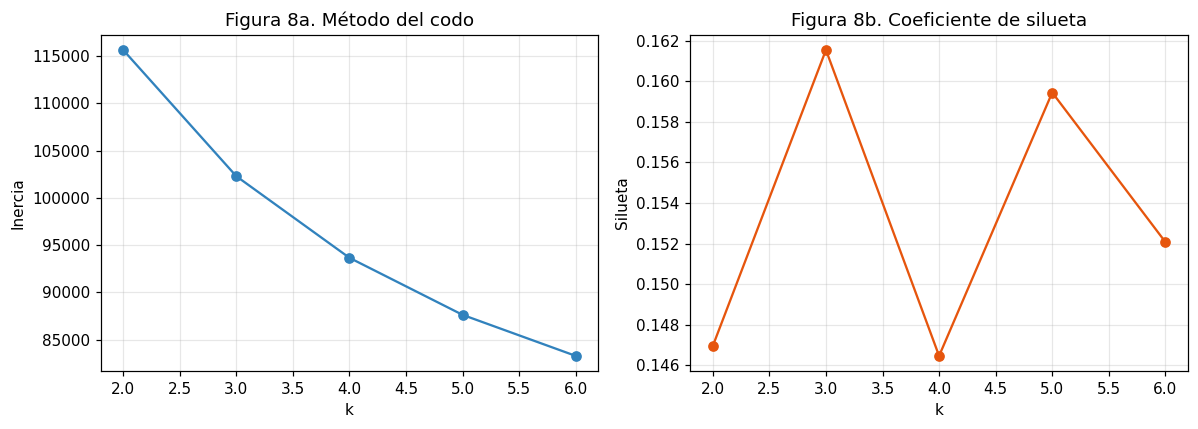

Silueta por k: ['2:0.147', '3:0.162', '4:0.146', '5:0.159', '6:0.152'] → k óptimo = 3


In [18]:
# ── K.1 K-Means: número óptimo de clusters ───────────────────────────────────
sc = rng.choice(idx_tr, size=30000, replace=False)
Z = preprocesador().fit_transform(X.iloc[sc])
ks=range(2,7); inercias=[]; siluetas=[]
for k in ks:
    km=KMeans(n_clusters=k, n_init=5, random_state=RNG).fit(Z)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Z[:5000], km.labels_[:5000]))
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(list(ks),inercias,'o-',color='#3182bd'); ax[0].set_title('Figura 8a. Método del codo'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inercia')
ax[1].plot(list(ks),siluetas,'o-',color='#e6550d'); ax[1].set_title('Figura 8b. Coeficiente de silueta'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silueta')
plt.tight_layout(); plt.savefig('figs/fig8_clusters_k.png', bbox_inches='tight'); plt.show()
k_opt=list(ks)[int(np.argmax(siluetas))]
print('Silueta por k:', [f'{k}:{s:.3f}' for k,s in zip(ks,siluetas)], '→ k óptimo =', k_opt)

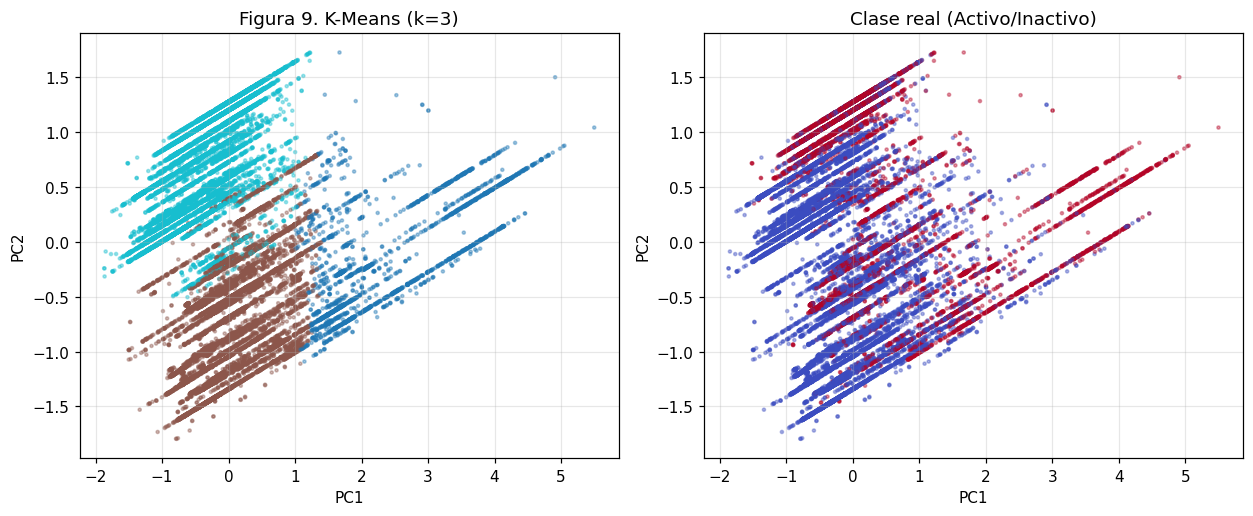

ARI (k=3) vs clase real: 0.041
ARI (k=2)      vs clase real: -0.000   (0 = azar, 1 = coincidencia perfecta)


In [19]:
# ── K.2 Comparación clusters vs clases reales (PCA 2D + ARI) ─────────────────
km = KMeans(n_clusters=k_opt, n_init=10, random_state=RNG).fit(Z)
cl = km.labels_; yv = y[sc]
P = PCA(n_components=2).fit_transform(Z)
ari_kopt = adjusted_rand_score(yv, cl)
ari_k2   = adjusted_rand_score(yv, KMeans(n_clusters=2, n_init=10, random_state=RNG).fit_predict(Z))

fig,ax=plt.subplots(1,2,figsize=(11.5,4.8))
sc0=ax[0].scatter(P[:,0],P[:,1],c=cl,cmap='tab10',s=4,alpha=.4); ax[0].set_title(f'Figura 9. K-Means (k={k_opt})')
ax[1].scatter(P[:,0],P[:,1],c=yv,cmap='coolwarm',s=4,alpha=.4); ax[1].set_title('Clase real (Activo/Inactivo)')
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.savefig('figs/fig9_clusters_pca.png', bbox_inches='tight'); plt.show()
print(f'ARI (k={k_opt}) vs clase real: {ari_kopt:.3f}')
print(f'ARI (k=2)      vs clase real: {ari_k2:.3f}   (0 = azar, 1 = coincidencia perfecta)')

In [20]:
# ── K.3 ¿Por qué agrupa K-Means? Composición de cada cluster ─────────────────
# Sustenta con datos la hipótesis de que los clusters responden a estructura
# geográfico-técnica (cuenca / método de extracción), no al estado operativo.
Xsc = X.iloc[sc].copy(); Xsc['cluster'] = cl
print('Composición de cada cluster por tipoextraccion (fila = cluster, % por fila):')
ct_ext = pd.crosstab(Xsc['cluster'], Xsc['tipoextraccion'], normalize='index')
display((ct_ext*100).round(1))
print('\nComposición de cada cluster por cuenca (%):')
ct_cu = pd.crosstab(Xsc['cluster'], Xsc['cuenca'], normalize='index')
display((ct_cu*100).round(1))
print('\nProporción de Activos dentro de cada cluster (para contrastar con la etiqueta):')
display(pd.Series(yv).groupby(cl).mean().round(3).rename('%_Activo').to_frame())

Composición de cada cluster por tipoextraccion (fila = cluster, % por fila):


tipoextraccion,Bombeo Hidráulico,Bombeo Mecánico,Cavidad Progresiva,Electrosumergible,Gas Lift,Jet Pump,Otros Tipos de Extracción,Pistoneo (Swabbing),Plunger Lift,Sin Sistema de Extracción,Surgencia Natural
cluster,,,,,,,,,,,
0,0.0,14.1,0.0,0.5,4.9,0.2,0.0,0.0,10.9,7.3,62.1
1,0.0,24.1,7.5,8.4,1.1,0.0,0.2,0.6,1.1,51.8,5.1
2,0.0,31.9,7.3,7.6,0.1,0.0,0.1,1.8,0.1,48.5,2.5



Composición de cada cluster por cuenca (%):


cuenca,AUSTRAL,CAÑADON ASFALTO,CUYANA,GOLFO SAN JORGE,NEUQUINA,NORESTE,NOROESTE
cluster,,,,,,,
0,1.9,0.0,0.8,0.2,91.0,0.0,6.1
1,3.7,0.0,11.4,0.0,83.1,0.0,1.7
2,5.3,0.0,0.0,94.5,0.0,0.0,0.1



Proporción de Activos dentro de cada cluster (para contrastar con la etiqueta):


,%_Activo
0,0.727
1,0.273
2,0.341


> **Interpretación del clustering.** Las siluetas son bajas (~0,15), señal de que la geometría de los datos **no presenta clusters fuertemente separados**. El **ARI** frente a las etiquetas reales es cercano a cero: las agrupaciones no supervisadas **no reproducen** la división Activo/Inactivo (lo confirma la última tabla: la proporción de Activos es similar entre clusters). En cambio, los *crosstabs* muestran que cada cluster **sí está dominado por combinaciones específicas de cuenca y método de extracción** —las variables de mayor varianza—, revelando subestructuras geográfico-técnicas que la clasificación supervisada, guiada por la etiqueta, no expone. Conclusión: el estado operativo no es la estructura dominante del espacio de features, por lo que el aprendizaje **supervisado** sigue siendo necesario para este target.

In [21]:
# ── L. Análisis de sensibilidad: aporte de tipoextraccion ────────────────────
# tipoextraccion domina la señal (ver Figura 5). Cuánto cae el mejor modelo si se lo quita.
feat_sin = [c for c in feat if c!='tipoextraccion']
def pre_sin():
    return ColumnTransformer([('num',RobustScaler(),num_feat),
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),[c for c in cat_feat if c!='tipoextraccion'])])
ss = rng.choice(idx_tr, size=150000, replace=False)
clf_sin = clone(modelos[mejor][0])                      # mismo tipo/config que el mejor modelo
p_sin = Pipeline([('pre',pre_sin()),('m',clf_sin)]).fit(X.iloc[ss][feat_sin], y[ss])
yp=p_sin.predict(X.iloc[idx_te][feat_sin]); pb=p_sin.predict_proba(X.iloc[idx_te][feat_sin])[:,1]
f1_con = tabla.set_index('Modelo').loc[mejor,'F1_weighted']; auc_con=tabla.set_index('Modelo').loc[mejor,'ROC_AUC']
print(f'{mejor} CON tipoextraccion : F1w={f1_con:.3f}  AUC={auc_con:.3f}')
print(f'{mejor} SIN tipoextraccion : F1w={f1_score(y[idx_te],yp,average="weighted"):.3f}  AUC={roc_auc_score(y[idx_te],pb):.3f}')
print('→ tipoextraccion es el predictor dominante, pero el resto de variables estructurales conserva señal.')

XGBoost CON tipoextraccion : F1w=0.879  AUC=0.943
XGBoost SIN tipoextraccion : F1w=0.807  AUC=0.900
→ tipoextraccion es el predictor dominante, pero el resto de variables estructurales conserva señal.


## Cuestionario de interpretación de resultados

> *Nota: los valores numéricos citados corresponden a la última corrida; tras re-ejecutar pueden variar de forma marginal sin alterar las conclusiones.*

**1. ¿Cuál fue el mejor clasificador y cambiaría con Recall vs Precision?**
El **XGBoost** obtuvo el mayor F1 ponderado (≈ 0,878) y AUC (≈ 0,941), seguido de cerca por Random Forest y el Árbol de Decisión; optimizado por `GridSearchCV` (Sección G) es el que se **adopta como modelo desplegable del TP4**. La elección es estable —lo confirma la validación cruzada estratificada-agrupada de la Sección G, con desvíos entre folds muy bajos—, pero el criterio depende del objetivo operativo. Todos los modelos, gracias al balanceo, alcanzan un **Recall de Activo muy alto (≈ 0,97–0,99)**: casi no dejan pasar pozos activos sin detectar (pocos falsos negativos), a costa de algo de Precisión de Activo (≈ 0,72–0,74; algunos inactivos etiquetados como activos). El **análisis de umbral (Figura 6)** hace explícito ese trade-off: si el objetivo fuera **auditar el parque inactivo** subiríamos el umbral para ganar Precisión (evitar falsas alarmas); si fuera **no perder ningún pozo productivo**, el umbral bajo por defecto ya maximiza el Recall. Las matrices de confusión muestran que el error se concentra en clasificar como Activos a algunos Inactivos (≈ 18 % de los Inactivos), no al revés.

**2. ¿Hubo sobreajuste o subajuste? Impacto del desbalance.**
Diagnosticado con **F1 ponderado** (métrica robusta al desbalance, no la accuracy): la columna `Brecha_F1w` (train − test) es pequeña en todos los modelos (< 0,02), lo que **descarta sobreajuste relevante**. La Regresión Logística y Naive Bayes tienen el techo más bajo (alto sesgo por su simplicidad, sin brecha); el Árbol, Random Forest y XGBoost logran mejor desempeño manteniendo brecha mínima —el `max_depth` y, en RF, el `class_weight` controlan la varianza—. Un matiz honesto: Random Forest se entrenó con 35 k filas frente a ~698 k del resto, de modo que su Recall algo menor refleja también ese menor volumen, no solo el modelo. Sobre el **desbalance** (1,95 : 1): sin tratarlo, la accuracy engaña (un modelo trivial saca 66 %); aplicar `class_weight='balanced'` elevó el Recall de la clase minoritaria. La comparación de la Sección J confirmó que `class_weight` y SMOTE rinden igual, por lo que se adoptó el primero por simplicidad y menor costo.

**3. ¿Qué factores del dominio explican el desempeño? ¿Clusters y ensambles?**
La **importancia de variables (Figura 5)** confirma que el predictor dominante es `tipoextraccion` (un pozo sin sistema de extracción instalado es estructuralmente inactivo), seguido por tipo de pozo y ubicación. El análisis de sensibilidad (Sección L) mostró que al quitar `tipoextraccion` el F1 ponderado cae de ≈ 0,88 a ≈ 0,81 pero el resto de variables estructurales conserva señal, evidenciando que la separabilidad es real y no depende de una única variable. El **clustering** no reprodujo las clases (ARI ≈ 0): los *crosstabs* de la Sección K muestran que las agrupaciones naturales responden a la geografía y el método de extracción, no al estado operativo, lo que justifica el enfoque supervisado. Los **ensambles** (RF, XGBoost) mejoraron marginalmente sobre los individuales; la ganancia en F1/AUC es modesta y, como muestra la columna `Tiempo_s`, se paga con un costo de entrenamiento e interpretabilidad mayor —se justifica solo por ese último punto de desempeño y por su mejor calibración de probabilidades (útil para el análisis de umbral)—.

## Conclusiones

Se abordó la clasificación binaria del estado operativo de los pozos con un marco experimental que atiende las dos particularidades del dato: el **panel** (partición agrupada por pozo, `StratifiedGroupKFold`) y el **desbalance** (estratificación y balanceo de clases). La decisión metodológica central fue **excluir las variables de producción y `tef`** para evitar un leakage que habría trivializado la tarea; aun así, el set puramente **estructural** clasifica con **F1 ponderado ≈ 0,878 y AUC ≈ 0,941**, muy por encima del baseline mayoritario (0,66). El **XGBoost**, optimizado por `GridSearchCV` con validación cruzada estratificada-agrupada, fue el mejor modelo y se serializó como **artefacto desplegable del TP4** (preprocesamiento + modelo en un único objeto), aunque los clasificadores simples ya resuelven bien el problema. El análisis de umbral hizo explícito el trade-off Precision-Recall según el objetivo operativo, y el clustering reveló que la estructura geométrica dominante es geográfico-técnica, no el estado operativo. La principal limitación es que el estado depende fuertemente de `tipoextraccion`, un atributo administrativo cercano al objetivo; incorporar variables independientes del registro de estado robustecería la generalización. Como trabajo futuro, se plantea explorar técnicas de clustering aptas para variables categóricas (K-Prototypes) y modelos calibrados para afinar la selección de umbral operativo.